In [1]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot


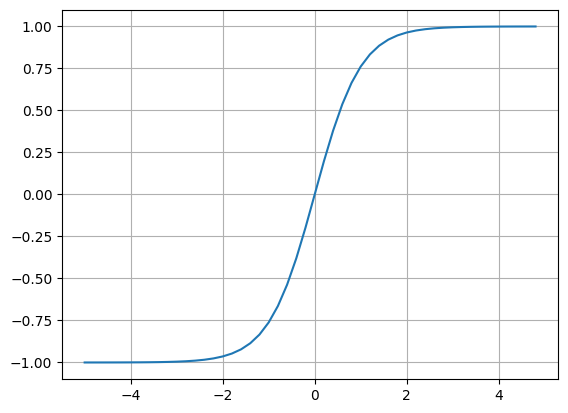

In [15]:
# tanh function

import random
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2))); plt.grid();

In [38]:
class Value:

    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        # We instantiate the constant
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __radd__(self, other):
        # other + self
        return self + other

    def __neg__(self):
        # -self
        return self * -1

    def __sub__(self, other):
        # self - other
        return self + (-other)

    def __mul__(self, other):
        # We instantiate the constant
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other):
        # other * self
        return self * other

    def __truediv__(self, other):
        # self / other
        other = other if isinstance(other, Value) else Value(other)
        return self * (other ** -1)

    def __rtruediv__(self, other):
        # other / self
        other = other if isinstance(other, Value) else Value(other)
        return other * (self ** -1)

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self, ), f"**{other}")
        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, (self, ), "tanh")
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), "exp")
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    

In [30]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # w * x + b
        pack = list(zip(self.w, x))
        print(pack)
        return 0.0

x = [2.0, 3.0]
n = Neuron(2)
n(x)

[(Value(data=-0.5518512017560304), 2.0), (Value(data=0.8146094918907505), 3.0)]


0.0

In [23]:
random.uniform(-1,1)

-0.3434977643483348

In [31]:
[Value(random.uniform(-1,1)) for _ in range(3)]

[Value(data=0.15491658926580376),
 Value(data=0.08798071248978734),
 Value(data=-0.8584240735986668)]

In [51]:
a = Value(2)
a + 1
1 + a

Value(data=3)

In [52]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # w * x + b
        act = sum(wi*xi for wi, xi in zip(self.w, x)) + self.b
        out = act.tanh()
        return out

x = [2.0, 3.0]
n = Neuron(2)
n(x)

Value(data=-0.7320170694056809)

In [59]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

x = [2.0, 3.0]
n = Neuron(2)
n(x)

Value(data=0.576961306874632)

In [64]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        act = self.b
        for wi, xi in zip(self.w, x):
            act = act + wi * xi
        return act.tanh()

x = [2.0, 3.0]
n = Neuron(2)
n(x)

Value(data=0.9678708920483496)

In [77]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

        # nin decides how many weights to create
        print(self.w, self.b)

    def __call__(self, x):
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
        
        # nout decides how many neurons to create
        print(self.neurons)
        print(len(self.neurons))

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


x = [2.0, 3.0]
n = Layer(2, 5)
n(x)

[Value(data=0.5750270951824858), Value(data=-0.7171978459898749)] Value(data=-0.2732674450114063)
[Value(data=0.9018040226839326), Value(data=-0.2520849793866051)] Value(data=-0.4654303187249136)
[Value(data=-0.8622566806912759), Value(data=-0.48239688305367445)] Value(data=-0.3703026618168632)
[Value(data=0.6191416931456213), Value(data=-0.6377911126666755)] Value(data=-0.12526713104900233)
[Value(data=0.4699238592336632), Value(data=-0.1251490838168383)] Value(data=-0.17390104979090304)
[<__main__.Neuron object at 0x7a4896ca9210>, <__main__.Neuron object at 0x7a4896ca9410>, <__main__.Neuron object at 0x7a4896cabb10>, <__main__.Neuron object at 0x7a4896caae50>, <__main__.Neuron object at 0x7a4896cabc50>]
5


[Value(data=-0.8550951013223306),
 Value(data=0.5240615476585424),
 Value(data=-0.998324601471414),
 Value(data=-0.6642363518964012),
 Value(data=0.37179069139130305)]

In [83]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

        # nin decides how many weights to create
        print("======= Neuron =======")
        print(self.w, self.b)

    def __call__(self, x):
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
        
        # nout decides how many neurons to create
        print("======= Layer =======")
        print(self.neurons)
        print(len(self.neurons))

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

        # nout decides how many neurons to create
        print("======= MLP =======")
        print(self.layers)
        print(len(self.layers))

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


x = [2.0, 3.0, -1.0]

# 3 inputs → 4 neurons → 4 neurons → 1 neuron
n = MLP(3, [4, 4, 1])

n(x)

======= Neuron =======
[Value(data=0.012007529310842147), Value(data=-0.5014094235027813), Value(data=-0.6512453746491946)] Value(data=-0.5286704101063304)
======= Neuron =======
[Value(data=0.19893989939554624), Value(data=0.4832864495792919), Value(data=0.3552154735962041)] Value(data=-0.444282267120504)
======= Neuron =======
[Value(data=-0.41127312106022096), Value(data=-0.4813048617222426), Value(data=-0.25156508247496023)] Value(data=-0.8508859316029427)
======= Neuron =======
[Value(data=-0.8840562039828943), Value(data=-0.26617701079112877), Value(data=0.28698874600579605)] Value(data=-0.84989222403077)
======= Layer =======
[<__main__.Neuron object at 0x7a4896b452d0>, <__main__.Neuron object at 0x7a4896ce1650>, <__main__.Neuron object at 0x7a4896ce1710>, <__main__.Neuron object at 0x7a4896c3f990>]
4
======= Neuron =======
[Value(data=0.4029960479185475), Value(data=-0.3414883918895637), Value(data=0.1018770428677187), Value(data=-0.31719466474811253)] Value(data=0.588646643809

[Value(data=0.10570845606412521)]

In [84]:
# Inputs        Hidden Layer 1        Hidden Layer 2        Output
# ------        --------------        --------------        ------

#  x1  o ─┬──►   o   o   o   o   ─┬──►  o   o   o   o   ─┬──►   o   y
#         │      |   |   |   |   │     |   |   |   |   │
#  x2  o ─┼──►   o   o   o   o   ─┼──►  o   o   o   o   ─┼──►
#         │      |   |   |   |   │     |   |   |   |   │
#  x3  o ─┴──►   o   o   o   o   ─┴──►  o   o   o   o   ─┴──►




# x1  x2  x3
#  |   |   |
#  o   o   o        ← input values (floats)
#   \  |  /
#    [ Neuron x4 ]  ← Layer 1
#         |
#    [ Neuron x4 ]  ← Layer 2
#         |
#       [ o ]       ← Output neuron

In [87]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


x = [2.0, 3.0, -1.0]

# 3 inputs → 4 neurons → 4 neurons → 1 neuron
n = MLP(3, [4, 4, 1])

n(x)

Value(data=-0.615582690374251)

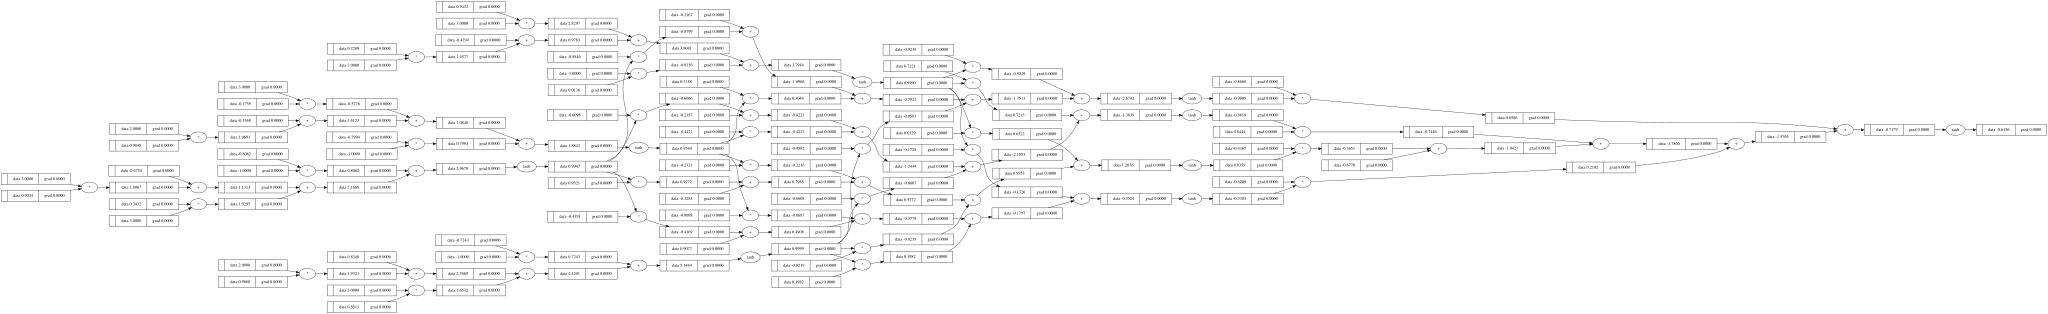

In [88]:
draw_dot(n(x))